In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (6, 4) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
adv=pd.read_csv('/content/drive/MyDrive/adverts.csv')

In [ ]:
adv.head()


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [ ]:
adv.tail()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
402000,202010315652942,5179.0,69,Grey,Peugeot,208,USED,2019.0,10595,Hatchback,False,Petrol
402001,202010315657341,110000.0,59,Red,Peugeot,107,USED,2009.0,2000,Hatchback,False,Petrol
402002,202010315659271,52760.0,62,White,Nissan,Qashqai,USED,2012.0,7250,SUV,False,Petrol
402003,202011015662436,10250.0,65,Red,Abarth,595,USED,2015.0,11490,Hatchback,False,Petrol
402004,201512149444029,14000.0,14,Silver,Audi,A4 Avant,USED,2014.0,20520,Estate,False,Diesel


In [ ]:
#Remove public reference column
adv= adv.drop('public_reference', axis=1)

In [ ]:
adv.shape

(402005, 11)

In [ ]:
adv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                401878 non-null  float64
 1   reg_code               370148 non-null  object 
 2   standard_colour        396627 non-null  object 
 3   standard_make          402005 non-null  object 
 4   standard_model         402005 non-null  object 
 5   vehicle_condition      402005 non-null  object 
 6   year_of_registration   368694 non-null  float64
 7   price                  402005 non-null  int64  
 8   body_type              401168 non-null  object 
 9   crossover_car_and_van  402005 non-null  bool   
 10  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(7)
memory usage: 31.1+ MB


In [ ]:
#Descriptive Stats.
adv[['mileage','year_of_registration','price']].describe().round().T

,count,mean,std,min,25%,50%,75%,max
mileage,401878.0,37744.0,34832.0,0.0,10481.0,28630.0,56876.0,999999.0
year_of_registration,368694.0,2015.0,8.0,999.0,2013.0,2016.0,2018.0,2020.0
price,402005.0,17342.0,46437.0,120.0,7495.0,12600.0,20000.0,9999999.0


In [ ]:
#Descriptive stats of columns that have non-numeric columns:
adv[['standard_colour','fuel_type','body_type','standard_make','standard_model','vehicle_condition','reg_code','crossover_car_and_van']].describe()

,standard_colour,fuel_type,body_type,standard_make,standard_model,vehicle_condition,reg_code,crossover_car_and_van
count,396627,401404,401168,402005,402005,402005,370148,402005
unique,22,9,16,110,1168,2,72,2
top,Black,Petrol,Hatchback,BMW,Golf,USED,17,False
freq,86287,216929,167315,37376,11583,370756,36738,400210


In [ ]:
#Examine distributions
adv['crossover_car_and_van'].value_counts(normalize=True)*100

,proportion
crossover_car_and_van,
False,99.553488
True,0.446512


In [ ]:
adv['vehicle_condition'].value_counts(normalize=True)*100

,proportion
vehicle_condition,
USED,92.226714
NEW,7.773286


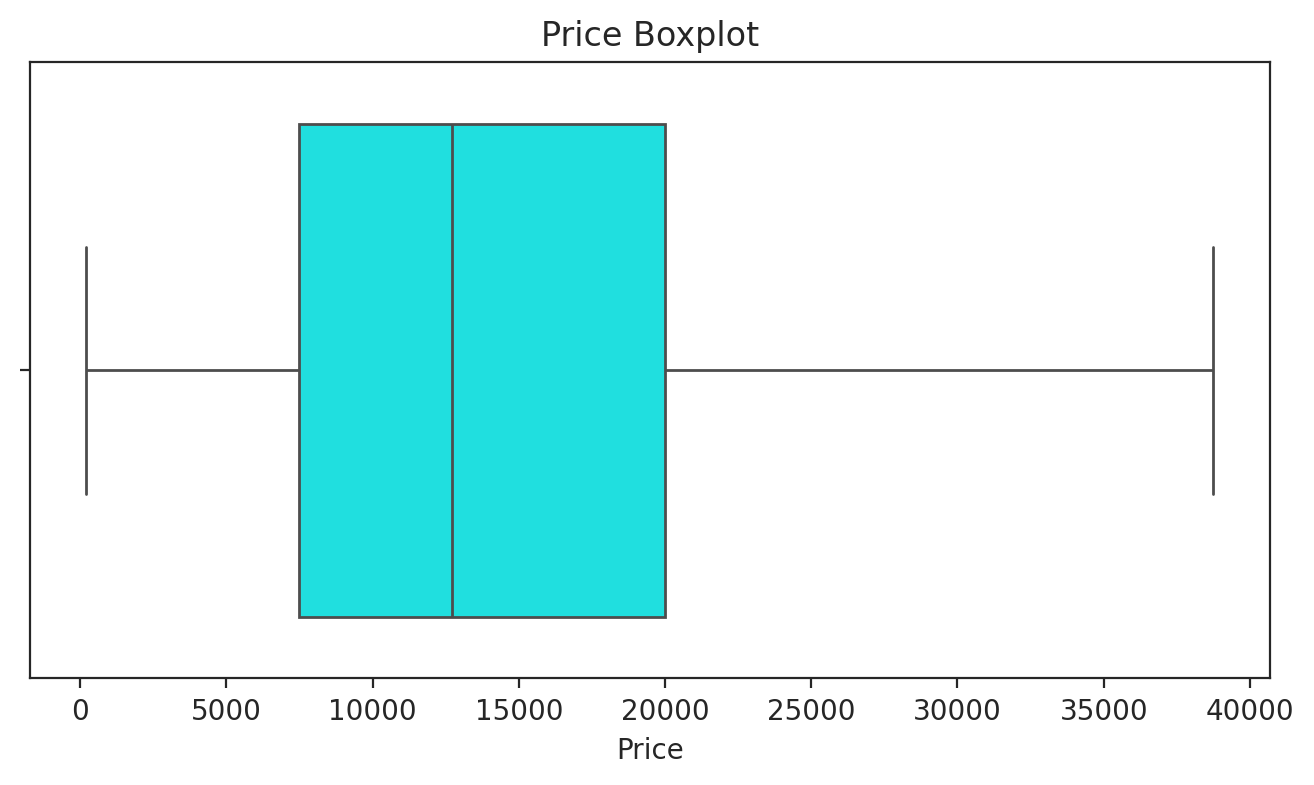

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='price', data=adv.sample(10000), color='cyan', showfliers=False)
plt.xlabel('Price')
plt.title('Price Boxplot')
plt.xlabel('Price')
plt.show()

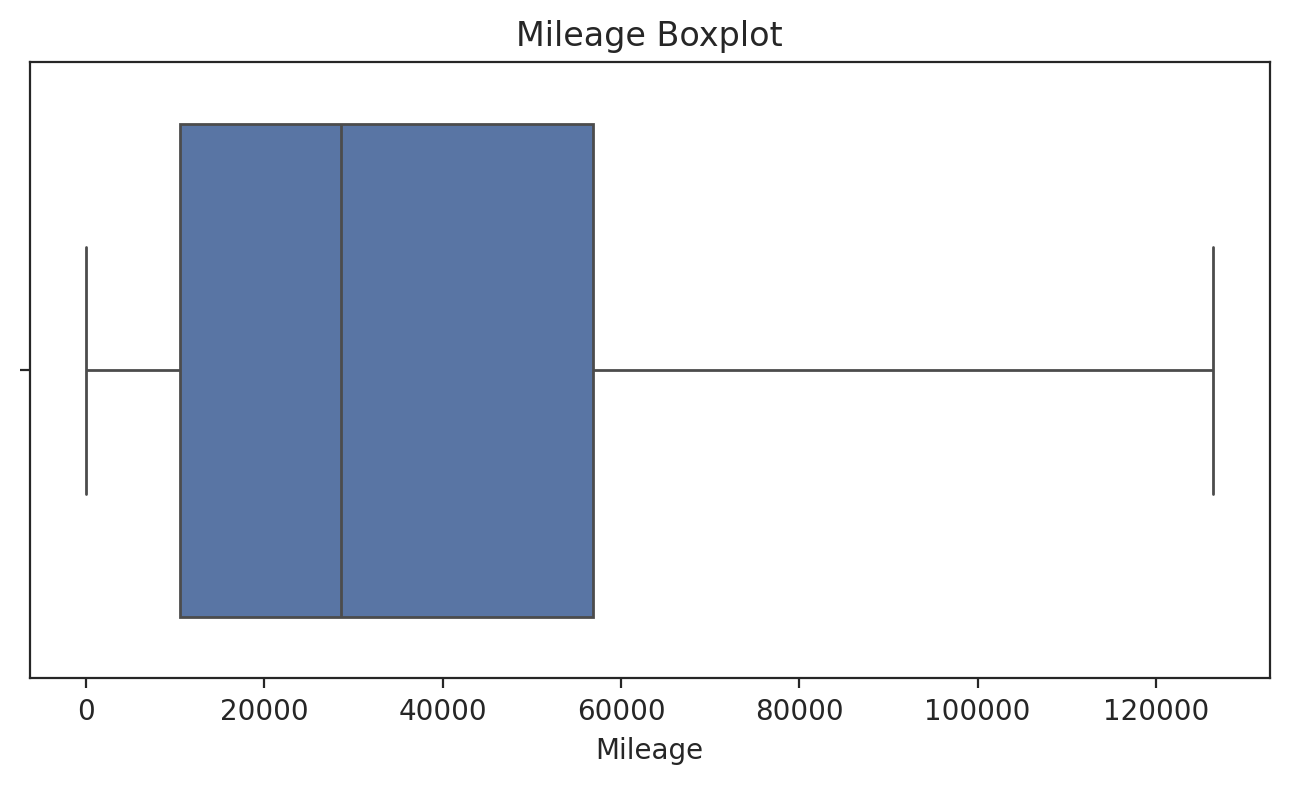

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='mileage', data=adv, showfliers=False)
plt.title('Mileage Boxplot')
plt.xlabel('Mileage')
plt.show()

In [ ]:
# year of reg <2000

adv_2000 = adv[adv['year_of_registration'] < 2000]
adv_2000

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
25,49585.0,B,NaN,Ferrari,308,USED,1984.0,54475,Convertible,False,Petrol
426,175000.0,J,Blue,Mercedes-Benz,SEC Series,USED,1991.0,19990,Coupe,False,Petrol
915,58980.0,D,Burgundy,Panther,Kallista,USED,1986.0,12950,Convertible,False,Petrol
951,82000.0,S,Grey,Renault,Clio,USED,1998.0,350,Hatchback,False,Petrol
1374,132522.0,H,Blue,Porsche,911,USED,1990.0,34950,Convertible,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
400664,5800.0,A,Blue,Fiat,500,USED,1963.0,9500,Saloon,False,Petrol
400710,150000.0,R,Green,Toyota,Picnic,USED,1998.0,1495,MPV,False,Petrol
400724,0.0,L,Silver,Porsche,911,USED,1973.0,175000,NaN,False,Petrol
401128,36000.0,M,White,Rolls-Royce,Silver Shadow,USED,1973.0,7495,Saloon,False,Petrol


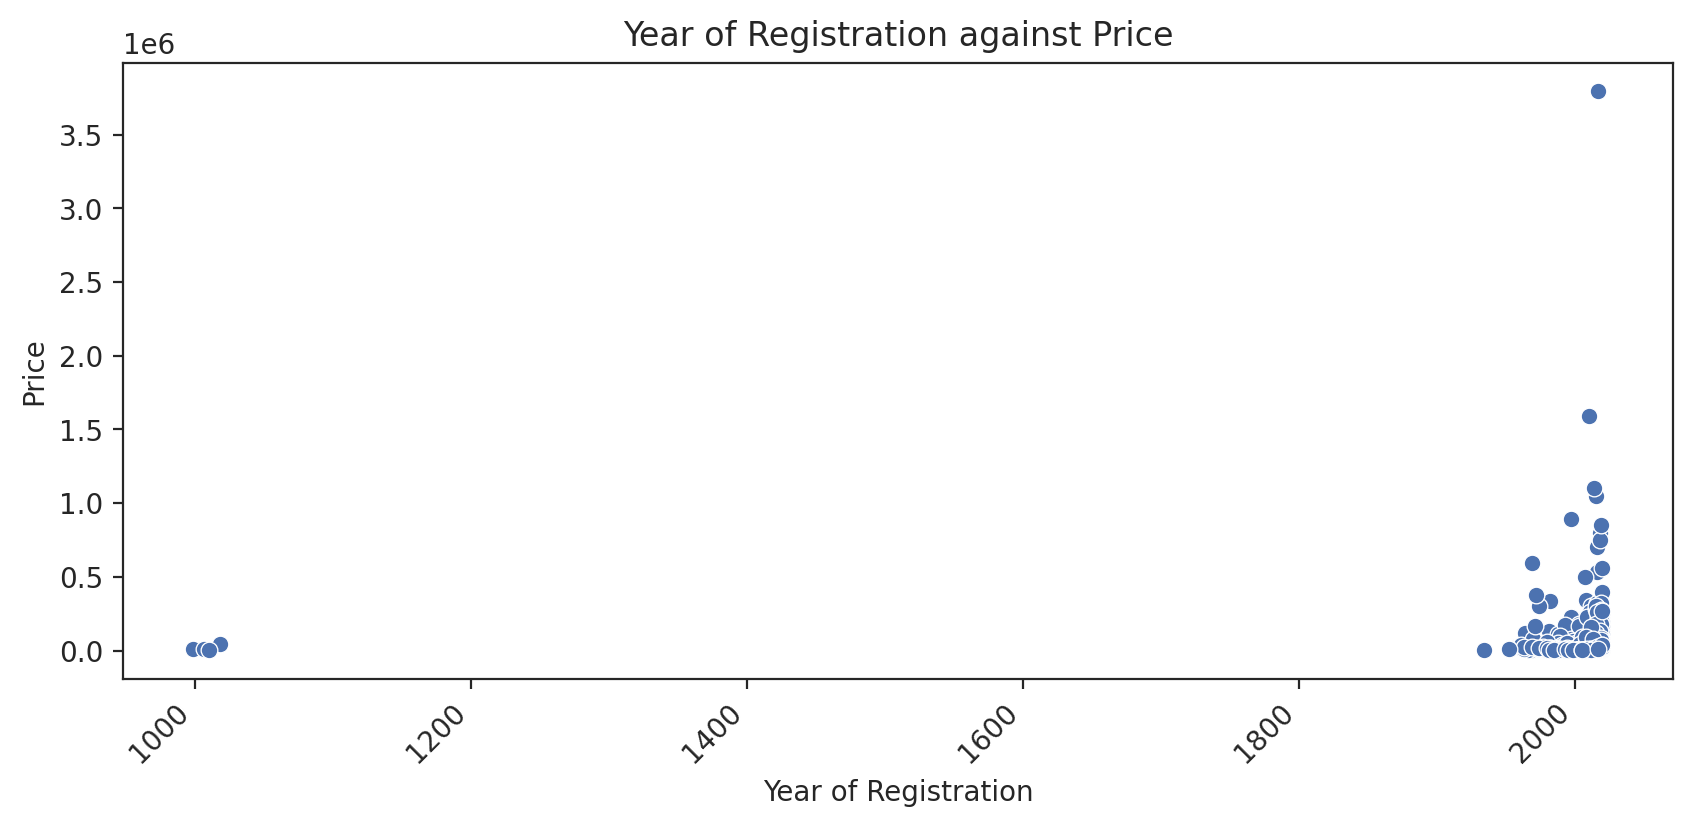

In [ ]:
#scatterplot of year of registration against price

plt.figure(figsize=(10, 4))
sns.scatterplot(x='year_of_registration', y='price', data=adv.sample(50000))
plt.xlabel('Year of Registration')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.title('Year of Registration against Price')
plt.show()


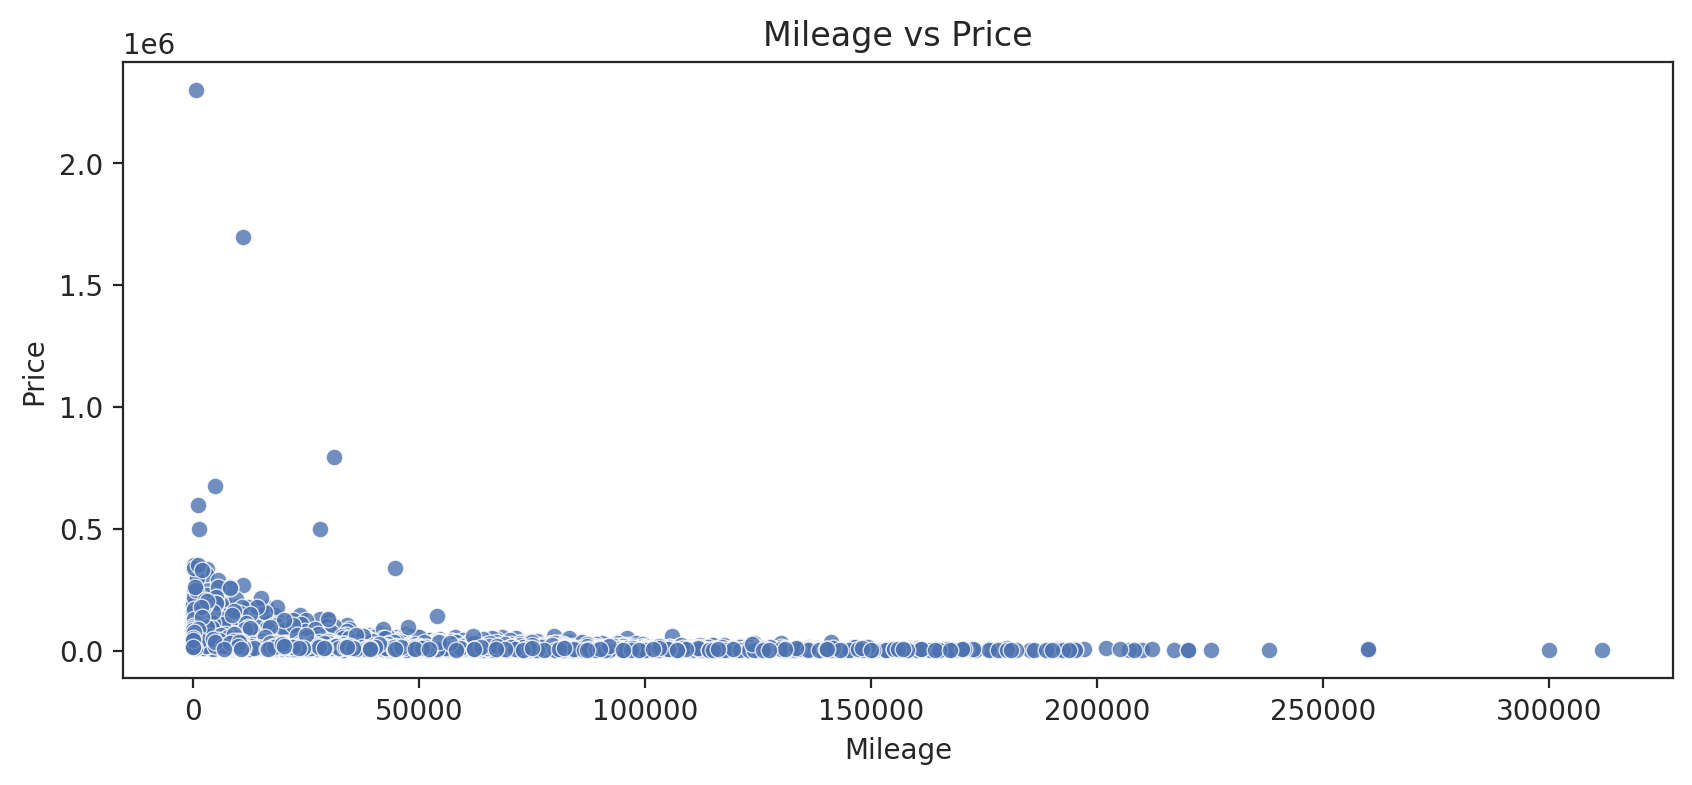

In [ ]:
#Examine relationships
plt.figure(figsize=(10, 4))
sns.scatterplot(x='mileage', y='price', data=adv.sample(20000),alpha=0.8)
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Mileage vs Price')
plt.show()


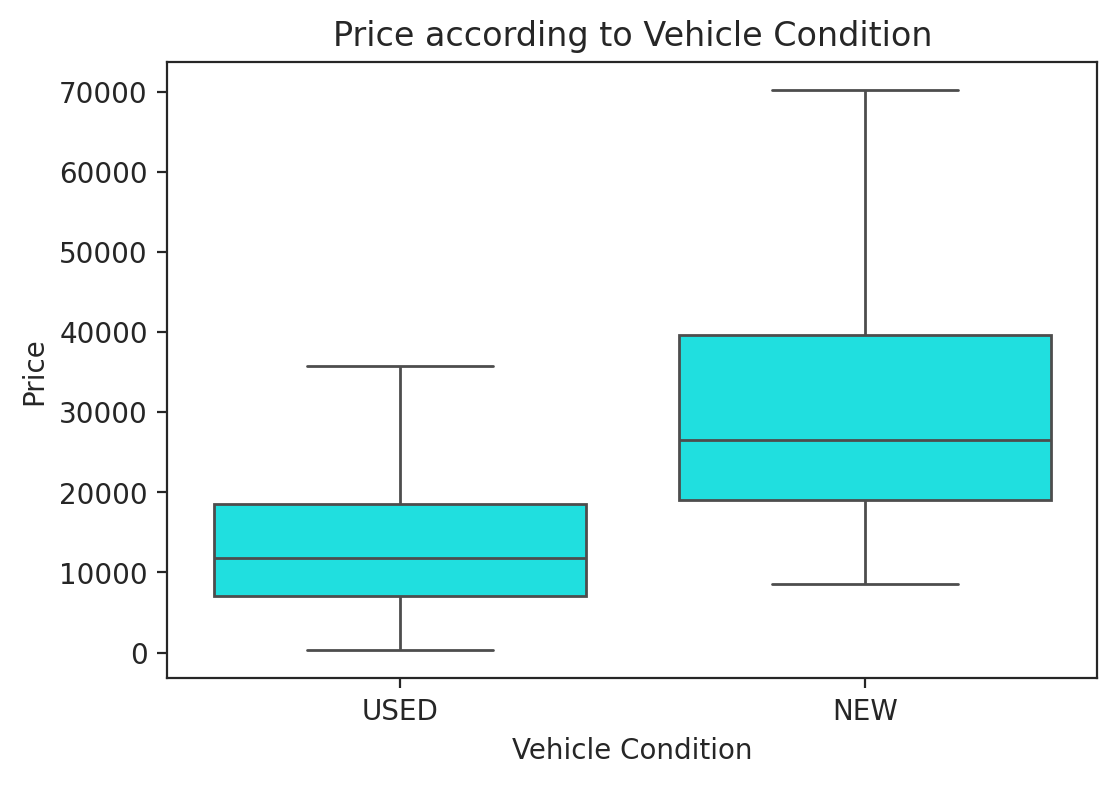

In [ ]:
#See relatioship between vehicle condition and price
sns.boxplot(data=adv.sample(50000), x='vehicle_condition', y='price',
            showfliers=False, color='cyan')
plt.xlabel('Vehicle Condition')
plt.ylabel('Price')
plt.title('Price according to Vehicle Condition')
plt.show()

In [ ]:
adv.loc[0:5, 'mileage':'price']

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price
0,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970
1,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000
2,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000
3,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995
4,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995
5,16000.0,17,Blue,Audi,S5,USED,2017.0,29000


In [ ]:
#Process price data for exploration and visualisation
sub_price=adv.loc[adv['price']<=100000]
sub_price.shape

(399191, 11)

In [ ]:
print(f'Vehicles under £100000 represent {(len(sub_price)/len(adv))*100:.2f} % of the data')

Vehicles under £100000 represent 99.30 % of the data


In [ ]:
##Process mileage data for exploration and visualisation
sub_mileage=adv.loc[adv['mileage']<=150000]
sub_mileage.shape



(399179, 11)

In [ ]:
adv_sub_1 = adv[(adv['mileage'] <= 150000) & (adv['price'] <= 100000)]


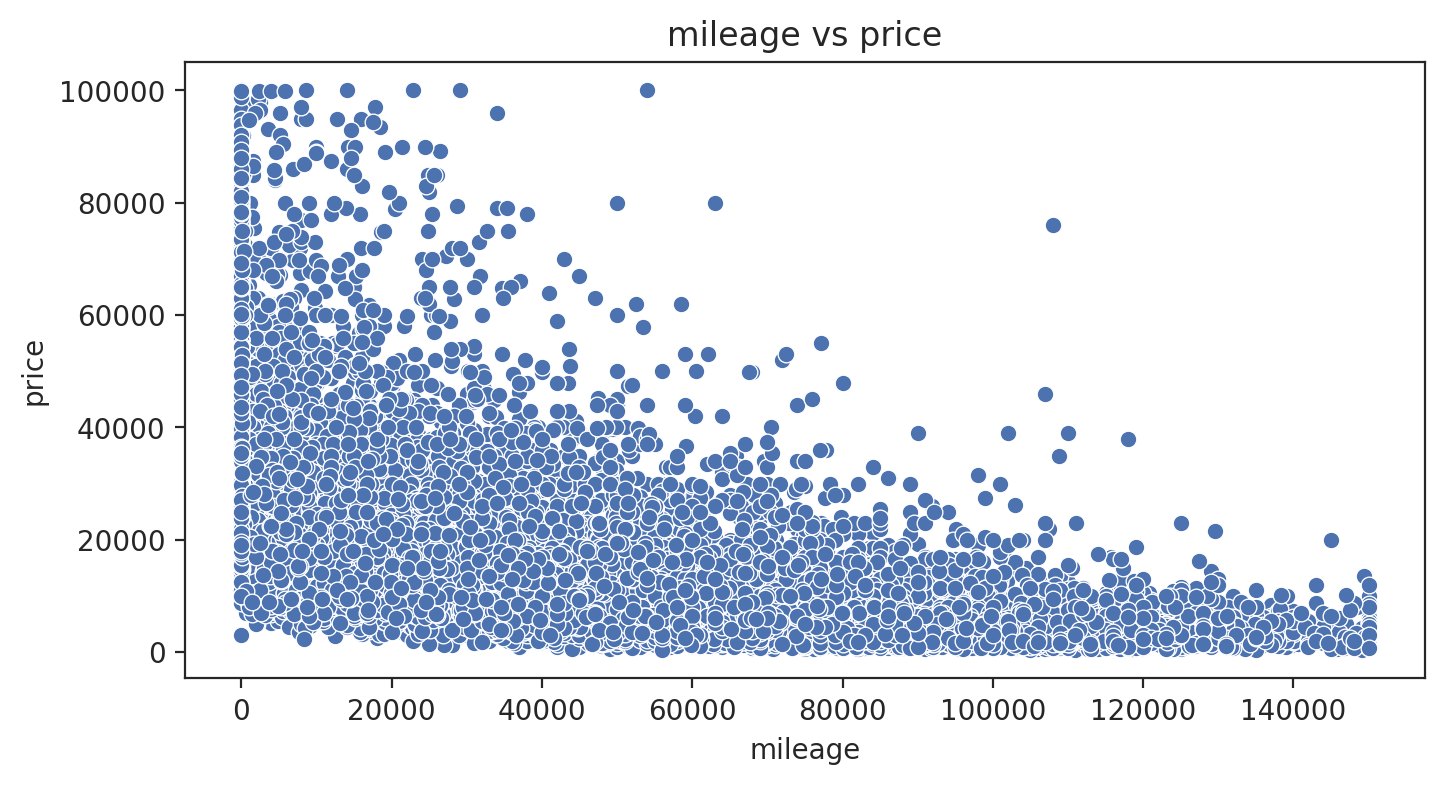

In [ ]:
plt.figure(figsize=(8, 4))
scatterplot=sns.scatterplot(data=adv_sub_1.sample(20000), x='mileage', y='price')
plt.title('mileage vs price') ;

In [ ]:
adv['body_type'].unique()

array(['SUV', 'Saloon', 'Hatchback', 'Convertible', 'Limousine', 'Estate',
       'MPV', 'Coupe', nan, 'Pickup', 'Combi Van', 'Panel Van', 'Minibus',
       'Window Van', 'Camper', 'Car Derived Van', 'Chassis Cab'],
      dtype=object)

In [ ]:
#Examine body_type distribution
sub_body=adv['body_type'].value_counts().nlargest(7)
sub_body

,count
body_type,
Hatchback,167315
SUV,115872
Saloon,36641
Estate,24692
Coupe,23258
Convertible,16038
MPV,16026


In [ ]:
print(f'The 7 most common body types are {(sum(sub_body))/len(adv)*100:.2f} % of the data')

The 7 most common body types are 99.46 % of the data


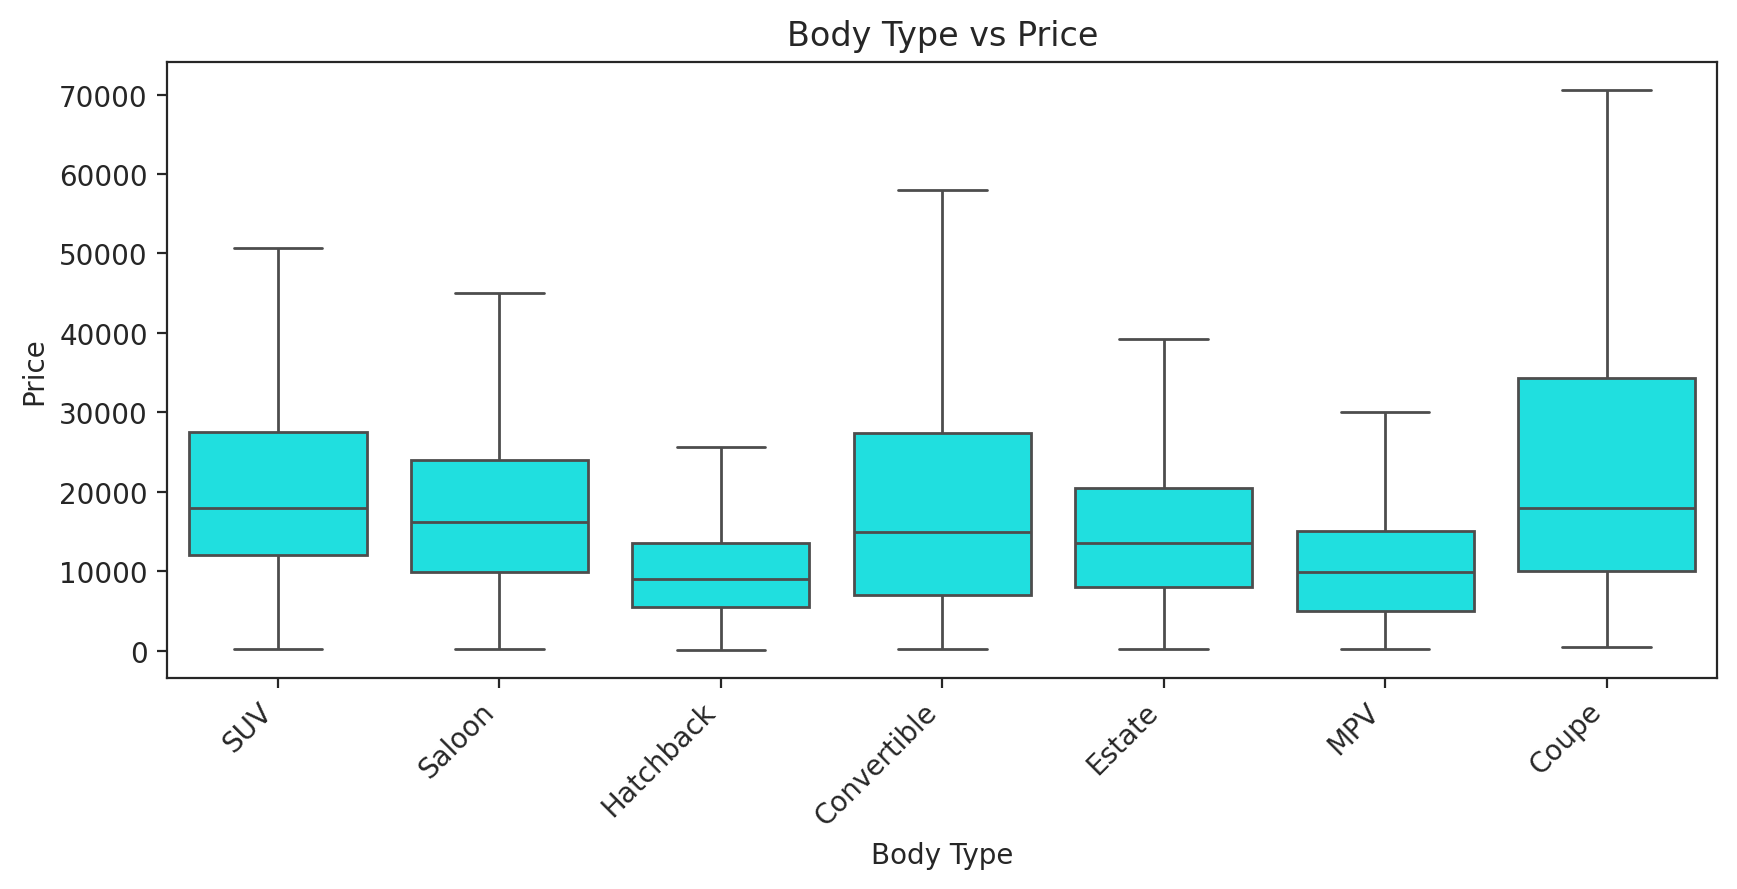

In [ ]:
# Boxplot of body type against price
data_top_body = adv[adv['body_type'].isin(sub_body.index)]
plt.figure(figsize=(10, 4))
sns.boxplot(data=data_top_body, x='body_type', y='price',showfliers=False, color='cyan')
plt.xlabel('Body Type')
plt.ylabel('Price')
plt.title('Body Type vs Price')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
sub_fuel=adv['fuel_type'].value_counts(normalize=True)*100
sub_fuel.nlargest(6).round(2)

,proportion
fuel_type,
Petrol,54.04
Diesel,39.39
Petrol Hybrid,3.39
Petrol Plug-in Hybrid,1.53
Electric,1.19
Diesel Hybrid,0.35


In [ ]:
print(f'The 2 most common fuel types are {sum(sub_fuel.nlargest(2)):.2f} % of the data')

The 2 most common fuel types are 93.43 % of the data


In [ ]:
mean_price_fuel_type = adv.groupby('fuel_type')['price'].mean()
mean_price_fuel_type.sort_values(ascending=False).round(2)

,price
fuel_type,
Diesel Hybrid,40469.16
Petrol Plug-in Hybrid,35986.69
Diesel Plug-in Hybrid,35633.69
Electric,32752.13
Petrol Hybrid,20289.12
Petrol,16620.44
Diesel,16505.05
Bi Fuel,14630.52
Natural Gas,3795.00


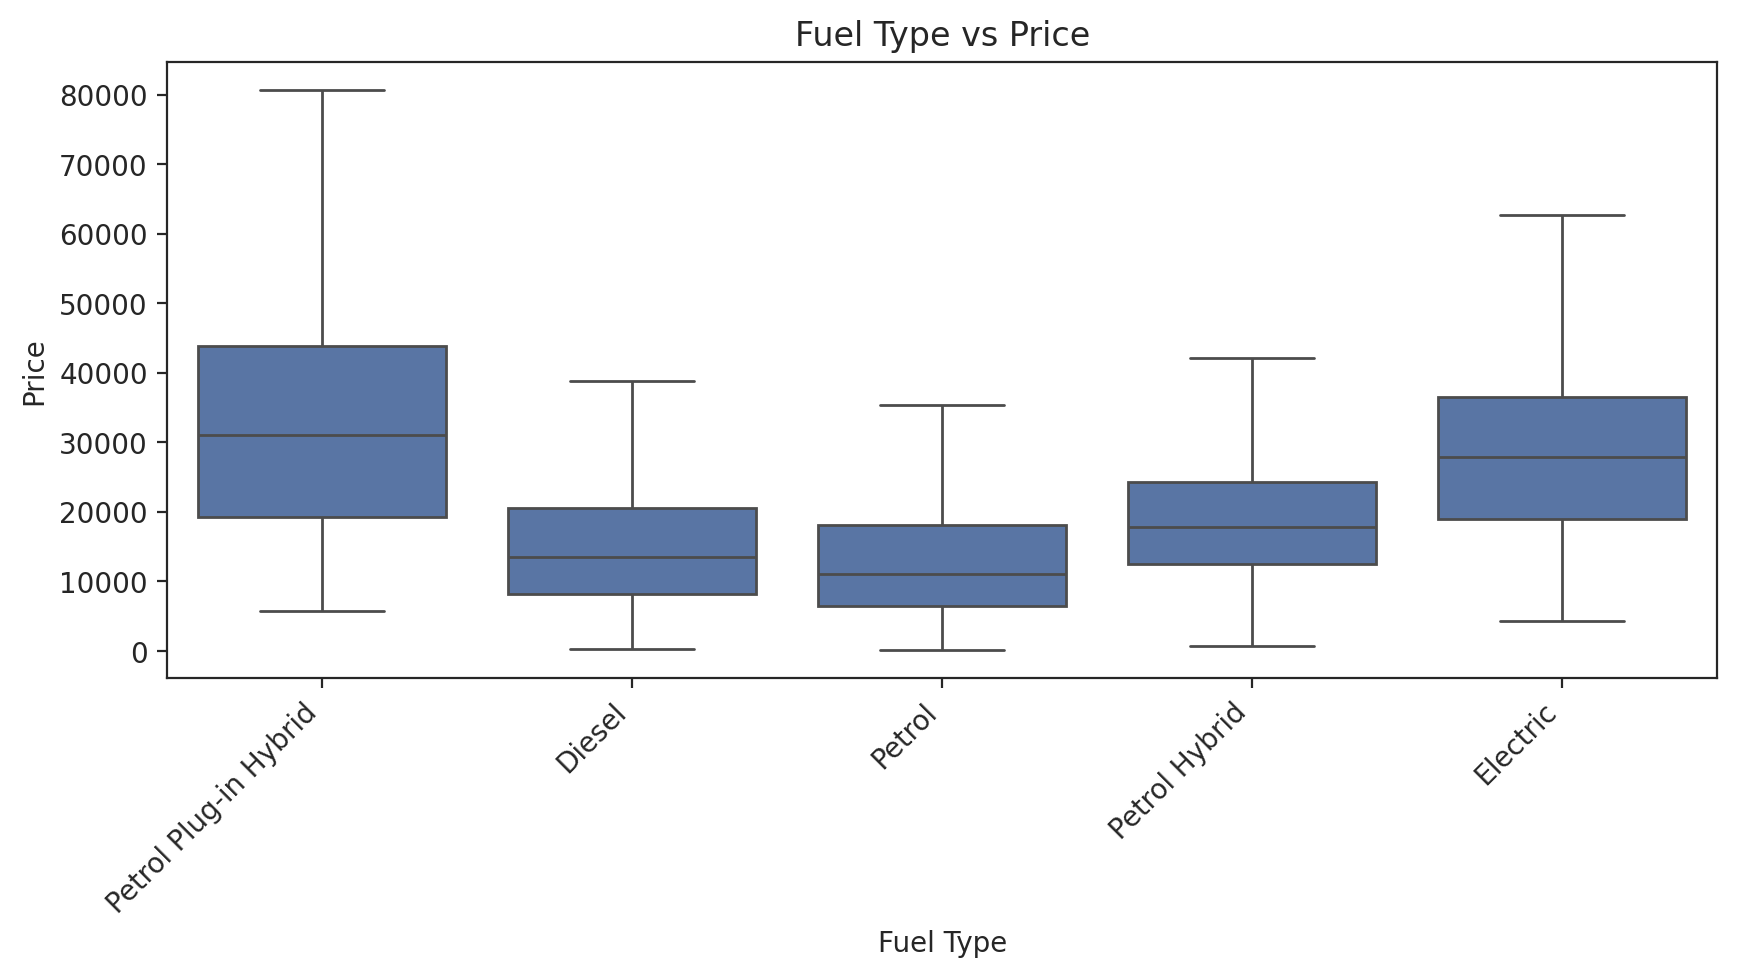

In [ ]:
# plot sub_body against price
top_fuel = adv[adv['fuel_type'].isin(sub_fuel.nlargest(5).index)]
plt.figure(figsize=(10, 4))
sns.boxplot(data=top_fuel, x='fuel_type', y='price',showfliers=False)
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.title('Fuel Type vs Price')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
# Examine distribution of values
make_counts = adv['standard_make'].value_counts(normalize=True) * 100

sub_make = make_counts.nlargest(6)

sub_make.round(2)

,proportion
standard_make,
BMW,9.30
Audi,8.78
Volkswagen,8.52
Vauxhall,8.38
Mercedes-Benz,7.94
Nissan,4.95


In [ ]:
print(f'The top 6 most common makes are {sub_make.sum():.2f} % of the data')

The top 6 most common makes are 47.86 % of the data


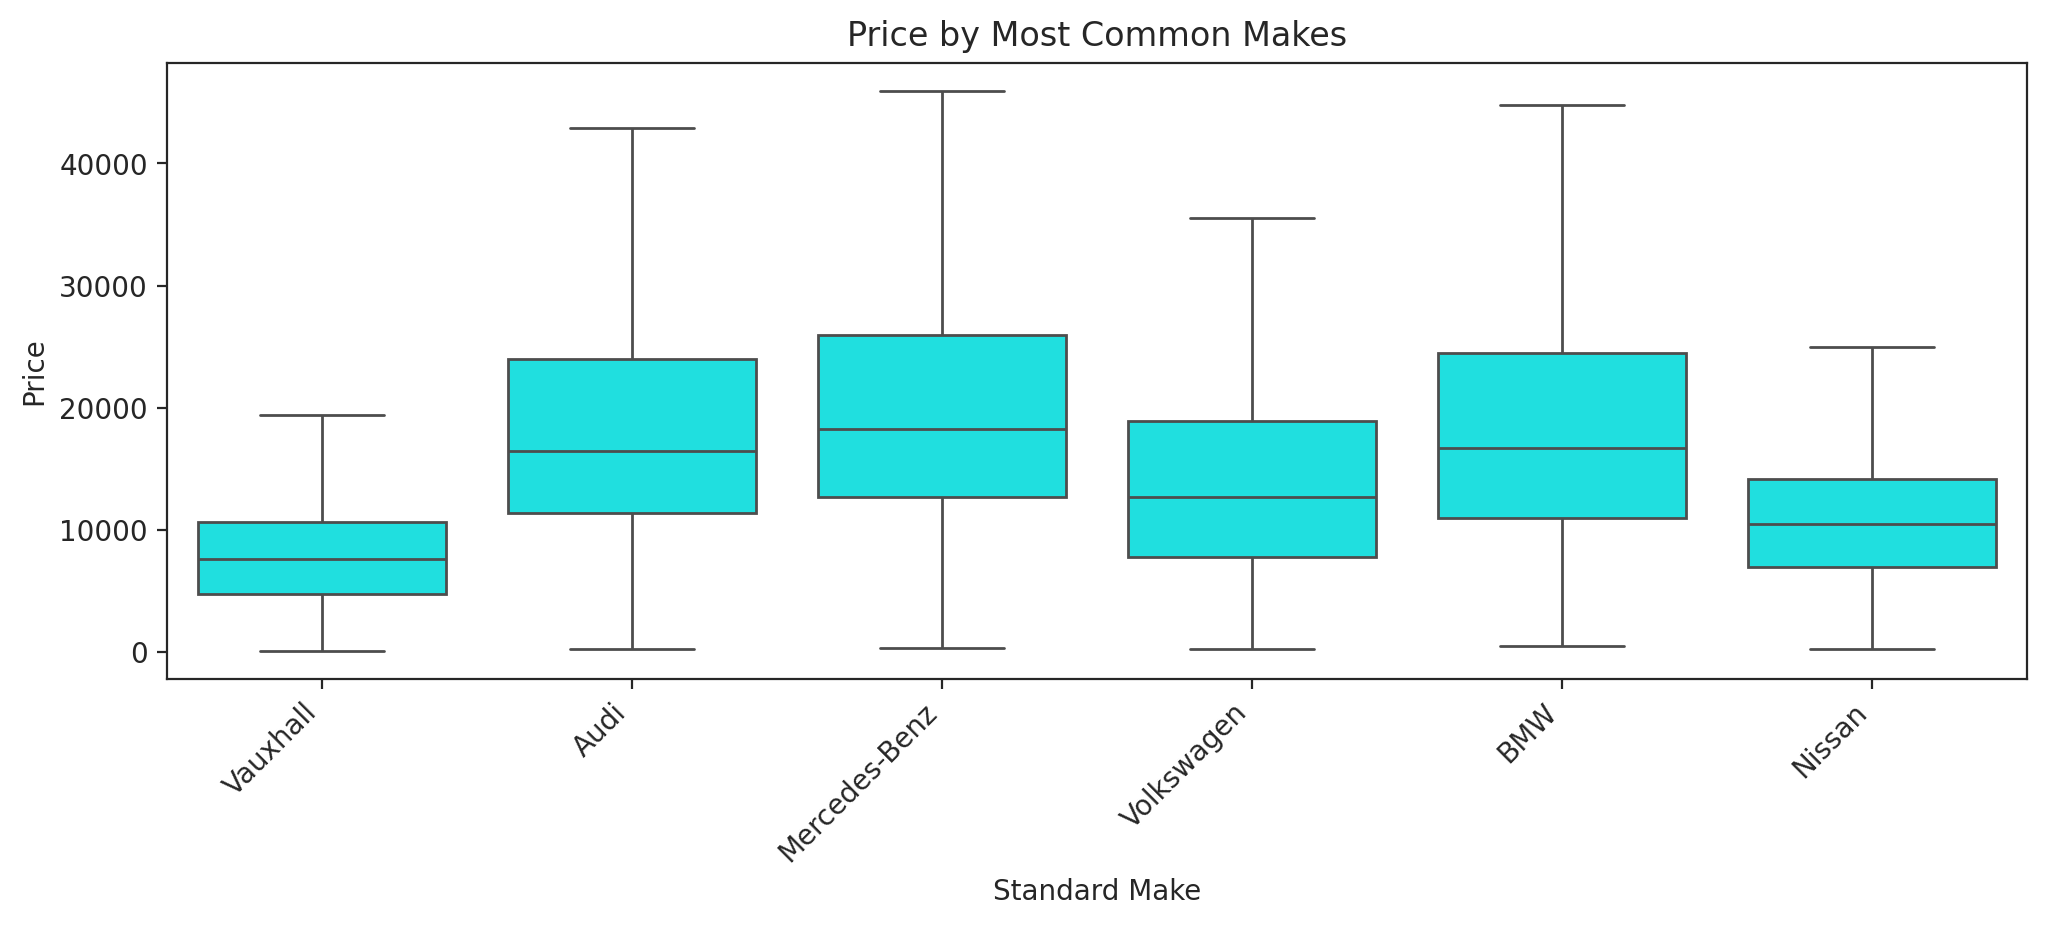

In [ ]:
top_makes = adv[adv['standard_make'].isin(sub_make.index)]

plt.figure(figsize=(12, 4))
sns.boxplot(x='standard_make', y='price', data=top_makes, showfliers=False, color='cyan')
plt.xlabel('Standard Make')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.title('Price by Most Common Makes')
plt.show()

In [ ]:
# Calculate the percentage of each coour
col_counts = adv['standard_colour'].value_counts(normalize=True) * 100

# Get the top 5 most common
sub_col = col_counts.nlargest(5)

sub_col.round(2)

,proportion
standard_colour,
Black,21.76
White,17.78
Grey,17.20
Blue,15.07
Silver,12.44


In [ ]:
mean_price_colour = adv.groupby('standard_colour')['price'].mean()
mean_price_colour.sort_values(ascending=False).round(2).head()

,price
standard_colour,
Indigo,27000.00
Yellow,24867.12
Grey,20036.61
Multicolour,18979.06
Black,18677.02


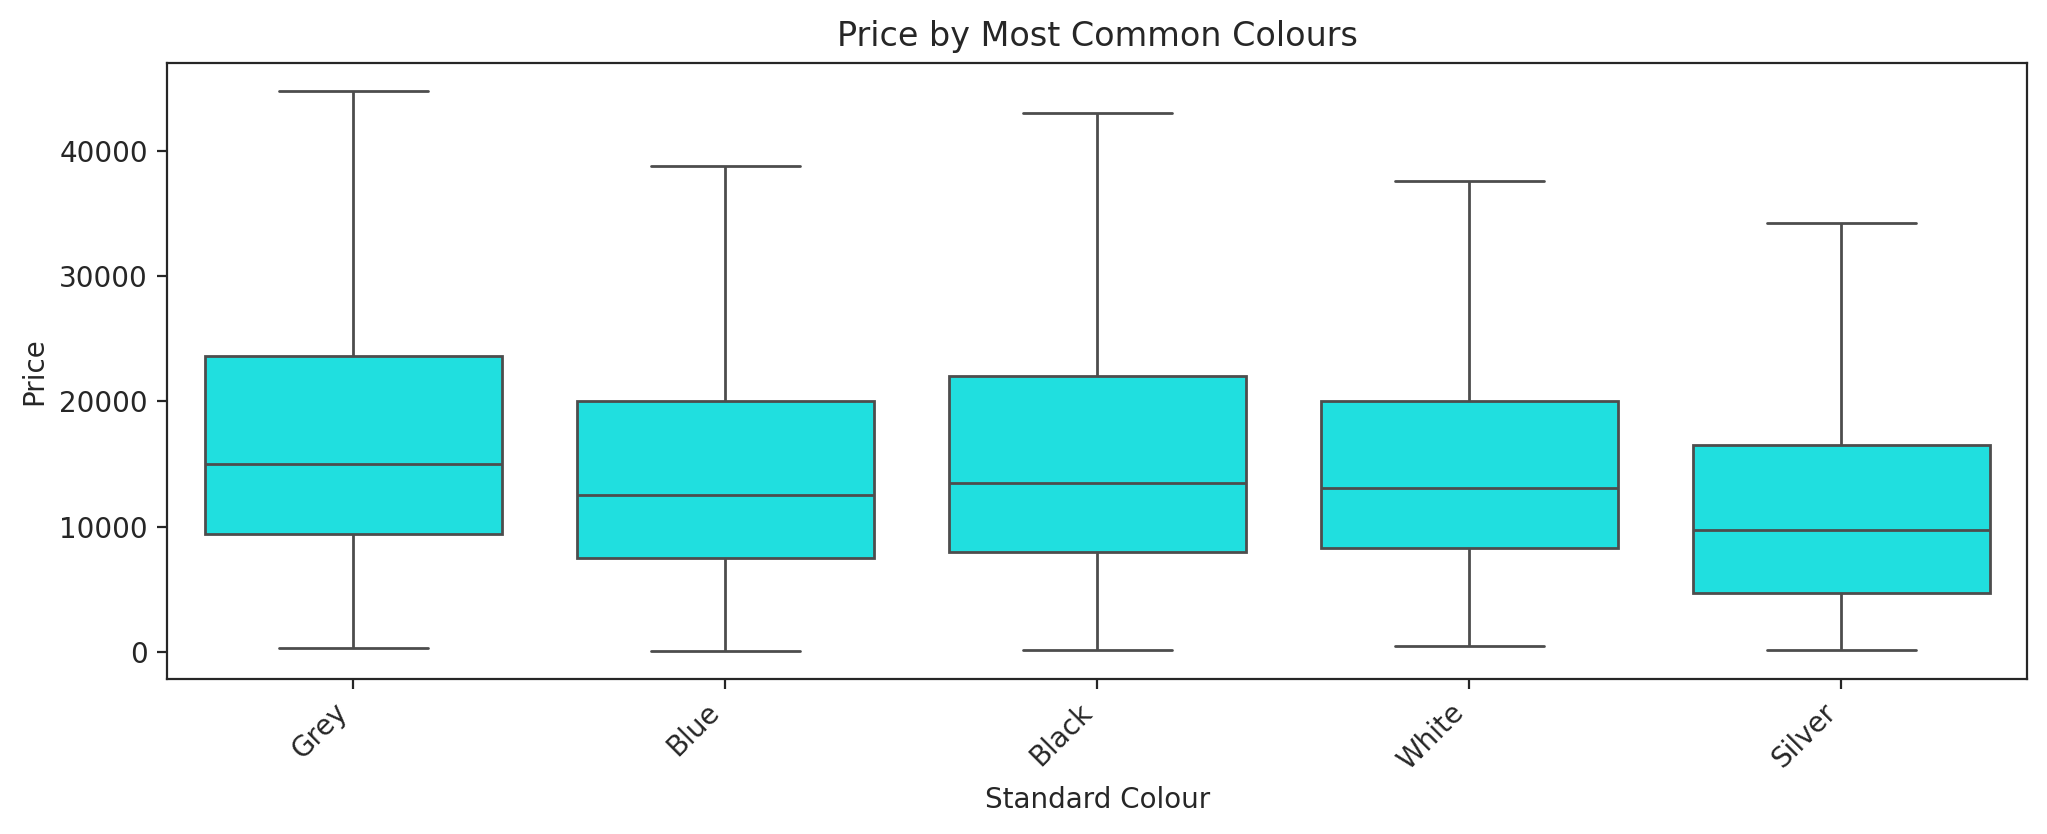

In [ ]:
top_colours = adv[adv['standard_colour'].isin(sub_col.index)]

plt.figure(figsize=(12, 4))
sns.boxplot(x='standard_colour', y='price', data=top_colours, showfliers=False, color='cyan')
plt.xlabel('Standard Colour')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.title('Price by Most Common Colours')
plt.show()

In [ ]:
mean_body = adv.groupby('body_type')['price'].mean()
mean_body.sort_values(ascending=False).round(2).head(6)

,price
body_type,
Limousine,58953.91
Coupe,35709.21
Camper,33197.58
Convertible,27015.14
SUV,22477.75
Minibus,20577.68


In [ ]:
#Examine outliers and noise
adv.loc[adv['year_of_registration']<1903].head()

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
59010,14000.0,07,Blue,Toyota,Prius,USED,1007.0,7000,Hatchback,False,Petrol Hybrid
69516,96659.0,65,Black,Audi,A4 Avant,USED,1515.0,10385,Estate,False,Diesel
84501,37771.0,63,Black,Smart,fortwo,USED,1063.0,4785,Coupe,False,Petrol
114737,30000.0,59,Red,Toyota,AYGO,USED,1009.0,4695,Hatchback,False,Petrol
120858,27200.0,66,Black,MINI,Clubman,USED,1016.0,18990,Estate,False,Diesel


In [ ]:
#Reload data if necessary
#adv=pd.read_csv('/content/drive/MyDrive/adverts.csv')
#adv = adv.drop('public_reference', axis=1)

In [ ]:
# change all non numeric values to null values
adv['reg_code'] = pd.to_numeric(adv['reg_code'], errors='coerce')

In [ ]:
# Most recent year of data we call max year.
max_year = adv['year_of_registration'].max()

In [ ]:
#Replace outlier values with year according to reg_code.
adv.loc[(adv['reg_code'] <= max_year-2000)
& (adv['year_of_registration']<=1903), 'year_of_registration'] = 2000 + adv['reg_code']

In [ ]:
adv.loc[((adv['reg_code'] > 50) &
         (adv['reg_code'] < 50 + (max_year-2000)))&
 (adv['year_of_registration'] <= 1903), 'year_of_registration'] = 2001 - 50 + adv['reg_code']

In [ ]:
adv['year_of_registration'].describe().round(2)

,year_of_registration
count,368694.00
mean,2015.05
std,4.36
min,1909.00
25%,2013.00
50%,2016.00
75%,2018.00
max,2020.00


In [ ]:
adv['year_of_registration'].value_counts(normalize=True).tail()*100

,proportion
year_of_registration,
1933.0,0.000542
1952.0,0.000542
1909.0,0.000271
1934.0,0.000271
1950.0,0.000271


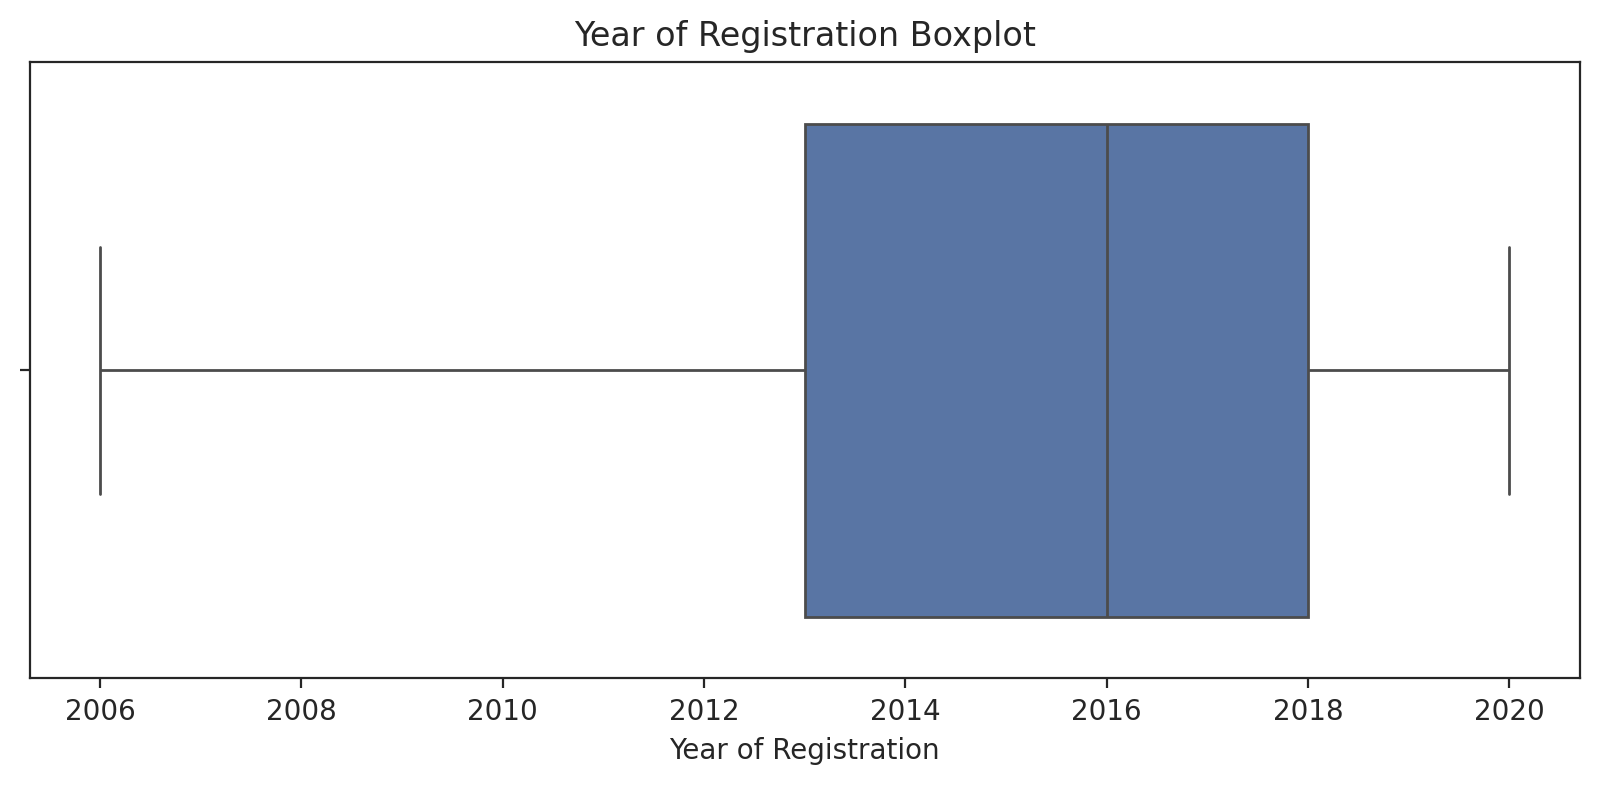

In [ ]:
# year of reg boxplot

plt.figure(figsize=(10, 4))
sns.boxplot(x='year_of_registration', data=adv, showfliers=False)
plt.xlabel('Year of Registration')
plt.title('Year of Registration Boxplot')
plt.show()

In [ ]:
#Examine null values
adv.isnull().sum()

,0
mileage,127
reg_code,34772
standard_colour,5378
standard_make,0
standard_model,0
vehicle_condition,0
year_of_registration,33311
price,0
body_type,837
crossover_car_and_van,0


In [ ]:
#Examine null values where vehicle condition is new and mileage <200
adv.loc[(adv['vehicle_condition'] =='NEW')&
 (adv['year_of_registration'].isnull())&
        (adv['mileage']<200)].head()

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
17,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
19,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
37,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
44,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol


In [ ]:
#If vehicle condition is new and mileage <200 replace year of reg values with the most recent year.

adv.loc[(adv['vehicle_condition'] == 'NEW') &
         (adv['year_of_registration'].isnull()) &
         (adv['mileage'] < 200), 'year_of_registration'] = max_year

In [ ]:
adv['year_of_registration'].isnull().sum()

2062

In [ ]:
#Use reg_code column to calculate missing years
adv.loc[(adv['reg_code'] <= max_year-2000)
& (adv['year_of_registration'].isnull()), 'year_of_registration'] = 2000 + adv['reg_code']

In [ ]:
adv.loc[((adv['reg_code'] > 50) & (adv['reg_code'] < 50 + (max_year-2000)))
& (adv['year_of_registration'].isnull()), 'year_of_registration'] = 2001 - 50 + adv['reg_code']

In [ ]:
adv['year_of_registration'].isnull().sum()

584

In [ ]:
adv.loc[adv['year_of_registration'].isnull()].head()

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
1510,13406.0,NaN,White,Land Rover,Range Rover Evoque,USED,NaN,26000,Coupe,False,Diesel
2356,499.0,70.0,Silver,Volkswagen,Arteon,USED,NaN,34999,Estate,False,Petrol
2631,1000.0,NaN,Blue,Maserati,Levante,USED,NaN,63995,SUV,False,Petrol
4408,40.0,70.0,Red,Volvo,V60,USED,NaN,32980,Estate,False,Petrol
4766,NaN,NaN,Grey,Subaru,Outback,USED,NaN,35995,Estate,False,Petrol


In [ ]:
# Drop rows with remaining null values in 'year_of_registration'
adv=adv.dropna(subset=['year_of_registration'])

In [ ]:
#Remove reg code column
adv.drop(['reg_code'], axis=1, inplace=True)


In [ ]:
# Filter the DataFrame for vehicles registered before 1990
adv_before_1990 = adv[adv['year_of_registration'] < 1990]

adv_before_1990



,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
25,49585.0,NaN,Ferrari,308,USED,1984.0,54475,Convertible,False,Petrol
915,58980.0,Burgundy,Panther,Kallista,USED,1986.0,12950,Convertible,False,Petrol
1733,165000.0,Blue,Land Rover,90,USED,1987.0,10489,SUV,True,Diesel
1801,159087.0,Beige,BMW,6 Series,USED,1987.0,28500,Coupe,False,Petrol
3399,461.0,Green,Aston Martin,DB6,USED,1970.0,950000,Convertible,False,Petrol
...,...,...,...,...,...,...,...,...,...,...
399882,9000.0,White,Porsche,911,USED,1972.0,100000,Coupe,False,Petrol
400391,32000.0,NaN,Triumph,Stag,USED,1974.0,12000,Convertible,False,Petrol
400664,5800.0,Blue,Fiat,500,USED,1963.0,9500,Saloon,False,Petrol
400724,0.0,Silver,Porsche,911,USED,1973.0,175000,NaN,False,Petrol


In [ ]:
# drop year if reg <1990

# Drop rows where 'year_of_registration' is less than 1990
adv = adv[adv['year_of_registration'] >= 1990]



In [ ]:
adv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400762 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                400652 non-null  float64
 1   standard_colour        395506 non-null  object 
 2   standard_make          400762 non-null  object 
 3   standard_model         400762 non-null  object 
 4   vehicle_condition      400762 non-null  object 
 5   year_of_registration   400762 non-null  float64
 6   price                  400762 non-null  int64  
 7   body_type              400043 non-null  object 
 8   crossover_car_and_van  400762 non-null  bool   
 9   fuel_type              400224 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 31.0+ MB


In [ ]:
# Find mileage IQR to deal with outliers
Q1 = adv['mileage'].quantile(0.25)
Q3 = adv['mileage'].quantile(0.75)
IQR = Q3 - Q1
print(Q3+1.5*IQR)

126168.625


In [ ]:
sub_mileage=adv.loc[adv['price']<=(Q3+1.5*IQR)]
sub_mileage.shape

(399026, 10)

In [ ]:
#Mileage 99% of values under Q3 + 1.5*IQR
print(f'{(len(sub_mileage)/len(adv))*100:.2f} % of the data')

99.57 % of the data


In [ ]:
#cap mileage values
upper_bound = Q3 + 1 * IQR
adv.loc[adv['mileage'] > upper_bound, 'mileage'] = upper_bound


In [ ]:
# drop  null values from mileage column

adv.dropna(subset=['mileage'], inplace=True)
adv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400652 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                400652 non-null  float64
 1   standard_colour        395405 non-null  object 
 2   standard_make          400652 non-null  object 
 3   standard_model         400652 non-null  object 
 4   vehicle_condition      400652 non-null  object 
 5   year_of_registration   400652 non-null  float64
 6   price                  400652 non-null  int64  
 7   body_type              399933 non-null  object 
 8   crossover_car_and_van  400652 non-null  bool   
 9   fuel_type              400114 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 30.9+ MB


In [ ]:
# replace null values in standard colour with mode colour

mode_colour = adv['standard_colour'].mode()[0]

adv['standard_colour'].fillna(mode_colour, inplace=True)

In [ ]:
#  drop standard_colour column - Not used

#adv = adv.drop('standard_colour', axis=1)



In [ ]:
adv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400652 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                400652 non-null  float64
 1   standard_colour        400652 non-null  object 
 2   standard_make          400652 non-null  object 
 3   standard_model         400652 non-null  object 
 4   vehicle_condition      400652 non-null  object 
 5   year_of_registration   400652 non-null  float64
 6   price                  400652 non-null  int64  
 7   body_type              399933 non-null  object 
 8   crossover_car_and_van  400652 non-null  bool   
 9   fuel_type              400114 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 30.9+ MB


In [ ]:
adv.loc[adv['body_type'].isnull()].head()

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
307,33287.0,Red,Volkswagen,Caddy,USED,2013.0,10990,NaN,False,Diesel
625,55000.0,Grey,Vauxhall,Vivaro,USED,2015.0,10995,NaN,False,Diesel
1256,18715.0,White,Volvo,V40,USED,2019.0,16950,NaN,False,Petrol
1643,24920.0,Blue,BMW,4 Series,USED,2017.0,21980,NaN,False,Diesel
1929,10.0,Blue,Lotus,Elise,USED,2020.0,47775,NaN,False,Petrol


In [ ]:
# Correct usage of dropna with the 'subset' argument
adv.dropna(subset=['fuel_type','body_type'], inplace=True)
adv.info()


<class 'pandas.core.frame.DataFrame'>
Index: 399454 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                399454 non-null  float64
 1   standard_colour        399454 non-null  object 
 2   standard_make          399454 non-null  object 
 3   standard_model         399454 non-null  object 
 4   vehicle_condition      399454 non-null  object 
 5   year_of_registration   399454 non-null  float64
 6   price                  399454 non-null  int64  
 7   body_type              399454 non-null  object 
 8   crossover_car_and_van  399454 non-null  bool   
 9   fuel_type              399454 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 30.9+ MB


In [ ]:
from scipy.stats.mstats import winsorize
adv['price'] = winsorize(adv['price'], limits=[0.05, 0.05])
adv['price'].describe().round(2)

,price
count,399454.00
mean,15364.64
std,10727.66
min,2495.00
25%,7495.00
50%,12550.00
75%,19995.00
max,43200.00


In [ ]:
adv['vehicle_condition'] = adv['vehicle_condition'].replace(['NEW', 'USED'], [0, 1])
adv['crossover_car_and_van']=adv['crossover_car_and_van'].astype(int)
adv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399454 entries, 0 to 402004
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   mileage                399454 non-null  float64
 1   standard_colour        399454 non-null  object 
 2   standard_make          399454 non-null  object 
 3   standard_model         399454 non-null  object 
 4   vehicle_condition      399454 non-null  int64  
 5   year_of_registration   399454 non-null  float64
 6   price                  399454 non-null  int64  
 7   body_type              399454 non-null  object 
 8   crossover_car_and_van  399454 non-null  int64  
 9   fuel_type              399454 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 33.5+ MB


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:
ohe = OneHotEncoder(sparse_output=False, max_categories=3)
ohe_1=ohe.fit_transform(adv[['fuel_type','standard_colour']])
ohe_1

,fuel_type_Diesel,fuel_type_Petrol,fuel_type_infrequent_sklearn,standard_colour_Black,standard_colour_White,standard_colour_infrequent_sklearn
0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
402000,0.0,1.0,0.0,0.0,0.0,1.0
402001,0.0,1.0,0.0,0.0,0.0,1.0
402002,0.0,1.0,0.0,0.0,1.0,0.0
402003,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
adv_1 = pd.concat([adv.drop(['fuel_type','standard_colour'], axis=1), pd.DataFrame(ohe_1)], axis=1)
adv_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399454 entries, 0 to 402004
Data columns (total 14 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   mileage                             399454 non-null  float64
 1   standard_make                       399454 non-null  object 
 2   standard_model                      399454 non-null  object 
 3   vehicle_condition                   399454 non-null  int64  
 4   year_of_registration                399454 non-null  float64
 5   price                               399454 non-null  int64  
 6   body_type                           399454 non-null  object 
 7   crossover_car_and_van               399454 non-null  int64  
 8   fuel_type_Diesel                    399454 non-null  float64
 9   fuel_type_Petrol                    399454 non-null  float64
 10  fuel_type_infrequent_sklearn        399454 non-null  float64
 11  standard_colour_Black          

In [ ]:
ohe_2 = OneHotEncoder(sparse_output=False, min_frequency=.01)

In [ ]:
ohe_2.fit_transform(adv[['body_type','standard_make','standard_model']])

,body_type_Convertible,body_type_Coupe,body_type_Estate,body_type_Hatchback,body_type_MPV,body_type_SUV,body_type_Saloon,body_type_infrequent_sklearn,standard_make_Audi,standard_make_BMW,...,standard_model_Corsa,standard_model_E Class,standard_model_Golf,standard_model_Hatch,standard_model_Juke,standard_model_Polo,standard_model_Qashqai,standard_model_Sportage,standard_model_Yaris,standard_model_infrequent_sklearn
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
402001,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
402002,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
402003,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
adv_2 = pd.concat([adv_1.drop(['body_type','standard_make','standard_model'], axis=1),
                   pd.DataFrame(ohe_2.fit_transform(adv_1[['body_type','standard_make','standard_model']]))], axis=1)
adv_2.shape

(399454, 63)

In [ ]:
adv_sub=adv_2.sample(50000)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
X = adv_sub.drop(columns='price')
y = adv_sub['price']
X.shape, y.shape

((50000, 62), (50000,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0,
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((37500, 62), (37500,), (12500, 62), (12500,))

In [ ]:
X_train.head()

,mileage,vehicle_condition,year_of_registration,crossover_car_and_van,fuel_type_Diesel,fuel_type_Petrol,fuel_type_infrequent_sklearn,standard_colour_Black,standard_colour_White,standard_colour_infrequent_sklearn,...,standard_model_Corsa,standard_model_E Class,standard_model_Golf,standard_model_Hatch,standard_model_Juke,standard_model_Polo,standard_model_Qashqai,standard_model_Sportage,standard_model_Yaris,standard_model_infrequent_sklearn
243500,14937.0,1,2018.0,0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
236070,27454.0,1,2017.0,0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
200571,32776.0,1,2018.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
363672,23094.0,1,2017.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
269628,16500.0,1,2019.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Use MinMax scaler. Without `set_output` we would have had a numpy array by default
scaler = MinMaxScaler().set_output(transform='pandas')

In [ ]:
scaler.fit(X_train)

MinMaxScaler()

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
X_train_scaled.head()

,mileage,vehicle_condition,year_of_registration,crossover_car_and_van,fuel_type_Diesel,fuel_type_Petrol,fuel_type_infrequent_sklearn,standard_colour_Black,standard_colour_White,standard_colour_infrequent_sklearn,...,standard_model_Corsa,standard_model_E Class,standard_model_Golf,standard_model_Hatch,standard_model_Juke,standard_model_Polo,standard_model_Qashqai,standard_model_Sportage,standard_model_Yaris,standard_model_infrequent_sklearn
243500,0.144974,1.0,0.933333,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
236070,0.266460,1.0,0.900000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
200571,0.318113,1.0,0.933333,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
363672,0.224143,1.0,0.900000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
269628,0.160144,1.0,0.966667,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#Model using KN regressor
regr = KNeighborsRegressor(n_neighbors=4)

In [ ]:
regr.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=4)

In [ ]:
# interpretation of the score: amount of variance of the target
regr.score(X_train_scaled, y_train), regr.score(X_test_scaled, y_test)

(0.8815490656527684, 0.8161102524200982)

In [ ]:
# interpretation of the loss: the average residual value
mean_absolute_error(y_train, regr.predict(X_train_scaled))

2214.09378

In [ ]:
mean_absolute_error(y_test, regr.predict(X_test_scaled))

2834.70624

In [ ]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import export_text

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, ParameterGrid

import sys
if 'google.colab' in sys.modules:
    !pip install -q dtreeviz
import dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
X, y = adv_sub.drop(columns='price'), adv_sub['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
dtr = DecisionTreeRegressor(max_depth=21)

In [ ]:
dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=21)

In [ ]:
dtr.score(X_train, y_train), dtr.score(X_test, y_test)

(0.962379562193548, 0.7583884916459501)

In [ ]:
mean_absolute_error(y_test, dtr.predict(X_test))

2996.4192661030183

In [ ]:
#Cross validation
from sklearn.model_selection import cross_validate

In [ ]:
scores_dict = cross_validate(dtr, X, y, return_train_score=True)

In [ ]:
dtr_scores = pd.DataFrame(scores_dict)

In [ ]:
dtr_scores

,fit_time,score_time,test_score,train_score
0,0.401929,0.009544,0.760941,0.951797
1,0.536031,0.014936,0.753559,0.949550
2,0.673781,0.014411,0.758155,0.953883
3,0.668968,0.015990,0.763413,0.958767
4,0.718403,0.014446,0.777060,0.948556


In [ ]:
#linear regression model
lr = LinearRegression()

In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
lr.coef_

array([-1.21377507e-01, -5.34558234e+03,  5.51136832e+02,  4.21163188e+03,
       -2.12668307e+03, -1.80203615e+03,  3.92871922e+03,  4.10891877e+02,
       -4.99238101e+02,  8.83462236e+01,  1.19221313e+03,  2.59940401e+03,
       -6.57512668e+02, -4.31250046e+03, -1.50007250e+03,  1.03128815e+03,
       -5.61635371e+02,  2.20881571e+03,  5.22970410e+03,  5.49587536e+03,
       -4.64715282e+03, -6.42214568e+03, -1.26523193e+03, -4.07890948e+03,
        6.41117762e+03, -4.33940782e+03,  1.23257191e+04, -3.24798338e+03,
       -2.05444140e+03,  5.72587974e+03, -2.57414578e+03, -4.27153493e+03,
        1.88400297e+04, -5.24036296e+03, -2.68574887e+03, -2.40598497e+03,
       -6.89697261e+03, -3.56502426e+03, -5.24616623e+03, -4.40417938e+02,
        4.55544260e+03,  7.97802796e+02, -2.24703803e+03, -2.52142431e+03,
       -1.11944165e+02,  9.84014362e+02, -5.86196139e+02, -3.81301779e+03,
       -1.55283403e+03,  3.12687282e+03, -2.01557214e+03,  2.60004034e+03,
        1.81916093e+03, -

In [ ]:
lr.score(X_train, y_train), lr.score(X_test, y_test)

(0.7218241096678033, 0.7342295481193095)

In [ ]:
mean_absolute_error(y_train, lr.predict(X_train))

4073.5294574332056

In [ ]:
mean_absolute_error(y_test, lr.predict(X_test))

3979.176131078695

In [ ]:
scores_dict = cross_validate(lr, X, y, return_train_score=True)

In [ ]:
lr_scores = pd.DataFrame(scores_dict)

In [ ]:
lr_scores

,fit_time,score_time,test_score,train_score
0,0.177361,0.005589,0.727834,0.727286
1,0.196371,0.005616,0.723356,0.728422
2,0.190753,0.005163,0.726489,0.727623
3,0.173045,0.009159,0.728217,0.727245
4,0.203691,0.005144,0.727484,0.727446


In [ ]:
#Hyper-Parameter Search with Grid Search
#Grid Search for KNN regressor
# Useful to see the underfitting and overfitting
param_grid = {
    'n_neighbors': [3, 4, 5, 7, 9, 11, 13, 15]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:

gs = GridSearchCV(regr, param_grid, return_train_score=True)

In [ ]:
gs.fit(X_train_scaled, y_train)

GridSearchCV(estimator=KNeighborsRegressor(n_neighbors=4),
             param_grid={'n_neighbors': [3, 4, 5, 7, 11, 13, 15]},
             return_train_score=True)

In [ ]:
gs_results = pd.DataFrame(gs.cv_results_)

In [ ]:
gs_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.020181,0.004063,2.969193,1.246451,3,{'n_neighbors': 3},0.802606,0.786551,0.797742,0.794582,...,0.793398,0.006545,4,0.895939,0.898243,0.899122,0.898054,0.898844,0.898041,0.001120
1,0.019350,0.013161,1.974740,0.940311,4,{'n_neighbors': 4},0.807706,0.798106,0.809081,0.800156,...,0.801190,0.006650,2,0.879131,0.884130,0.883475,0.883308,0.884328,0.882874,0.001911
2,0.012268,0.004264,1.925891,0.606045,5,{'n_neighbors': 5},0.808499,0.797759,0.809648,0.802751,...,0.802526,0.006038,1,0.868971,0.870750,0.871912,0.870890,0.872242,0.870953,0.001145
3,0.010220,0.000327,2.385851,1.099866,7,{'n_neighbors': 7},0.803125,0.794029,0.806970,0.800942,...,0.799020,0.006155,3,0.849449,0.853536,0.852412,0.852124,0.853826,0.852269,0.001551
4,0.012169,0.003973,1.979914,0.971714,11,{'n_neighbors': 11},0.787753,0.783595,0.796047,0.789164,...,0.785440,0.008416,5,0.823745,0.828159,0.825471,0.825193,0.828353,0.826184,0.001791


In [ ]:
#Rank results
gs_df = gs_results[[
    'param_n_neighbors',
    'mean_test_score', 'mean_train_score', 'std_test_score', 'std_train_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')
gs_df

,param_n_neighbors,mean_test_score,mean_train_score,std_test_score,std_train_score,rank_test_score
2,5,0.802526,0.870953,0.006038,0.001145,1
1,4,0.801190,0.882874,0.006650,0.001911,2
3,7,0.799020,0.852269,0.006155,0.001551,3
0,3,0.793398,0.898041,0.006545,0.001120,4
4,11,0.785440,0.826184,0.008416,0.001791,5
5,13,0.778257,0.814023,0.007808,0.001911,6
6,15,0.771745,0.803471,0.007401,0.001699,7


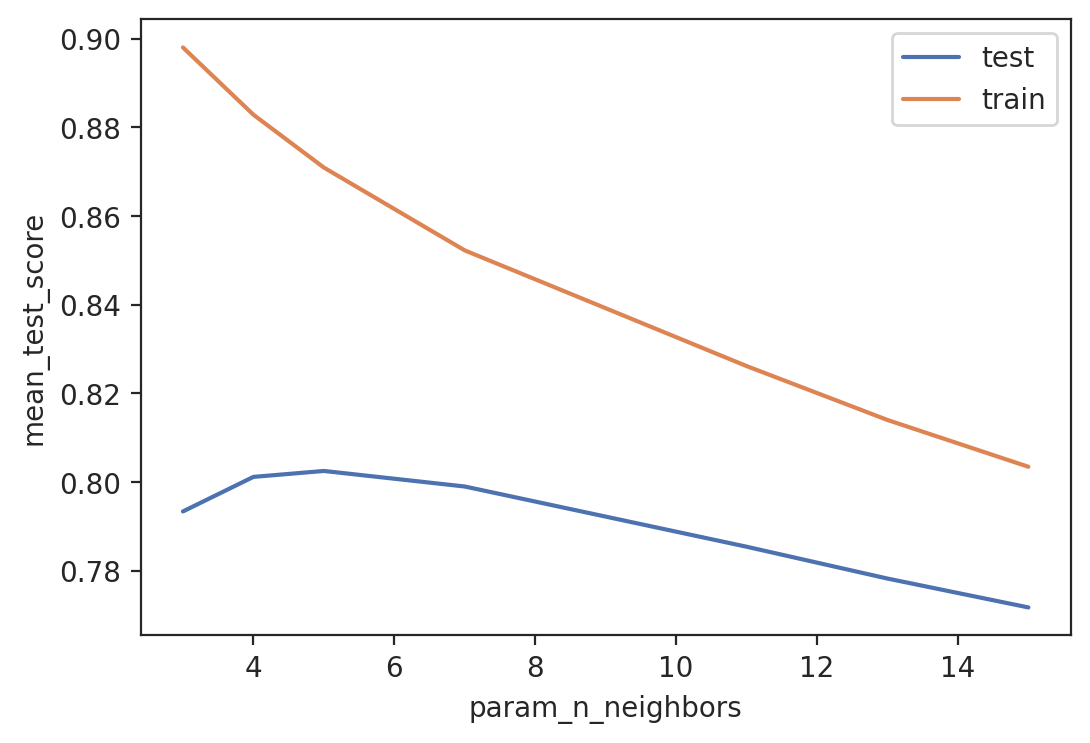

In [ ]:
#Visualise results
_ = sns.lineplot(data=gs_df, x='param_n_neighbors', y='mean_test_score', label='test')
_ = sns.lineplot(data=gs_df, x='param_n_neighbors', y='mean_train_score', label='train')

In [ ]:
my_gs_n_neighbors = gs.best_params_
my_gs_n_neighbors

{'n_neighbors': 5}

In [ ]:
# retraining the kNN regressor - now, with the dictionary containing the best
# configuration (`**` will expand a dictionary into arguments of the kNN regressor instantiation)
regr = KNeighborsRegressor(**gs.best_params_)

In [ ]:
scores_dict = cross_validate(regr, X_train_scaled, y_train, return_train_score=True)

In [ ]:
scores = pd.DataFrame(scores_dict)

In [ ]:
scores['train_score'].mean(), scores['train_score'].std()

(0.8709531922782615, 0.0012803678746913492)

In [ ]:
scores['test_score'].mean(), scores['test_score'].std()

(0.8025264951613431, 0.006750990267850746)

In [ ]:
#Model evaluation
from sklearn.metrics import PredictionErrorDisplay

In [ ]:
regr.fit(X_train, y_train)

KNeighborsRegressor()

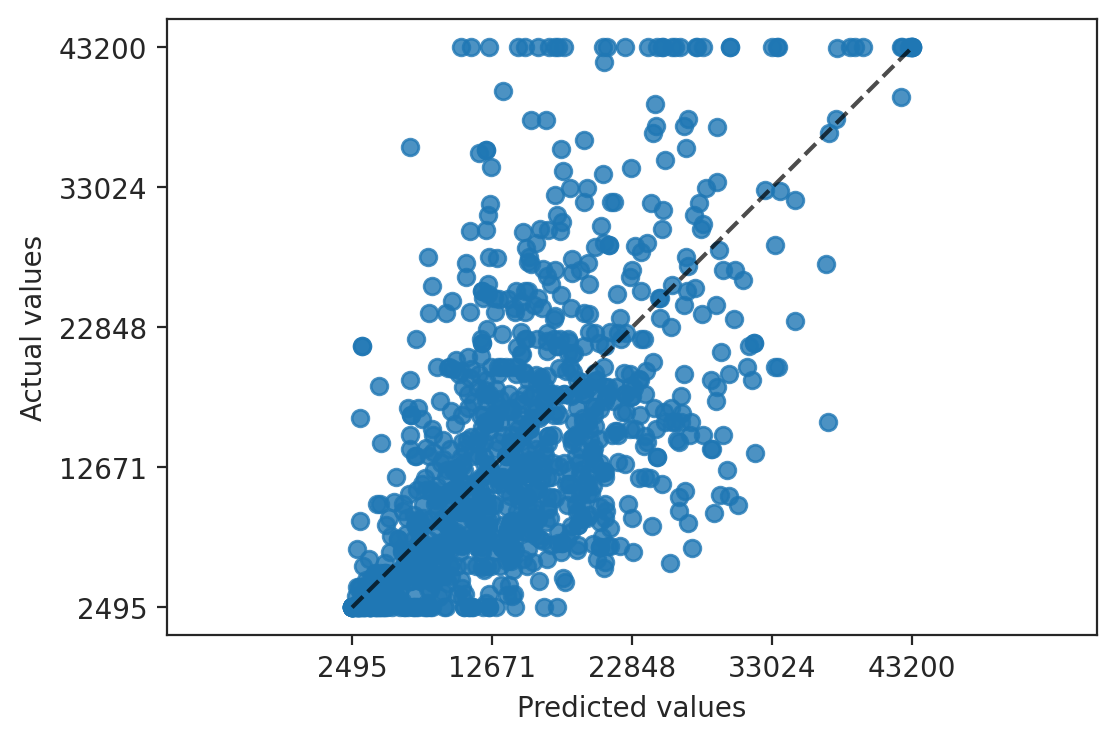

In [ ]:
PredictionErrorDisplay.from_estimator(regr, X_test, y_test, kind='actual_vs_predicted');

In [ ]:
y_pred = pd.Series(regr.predict(X_test), index=X_test.index).rename('y_pred')
residuals_test = y_pred - y_test

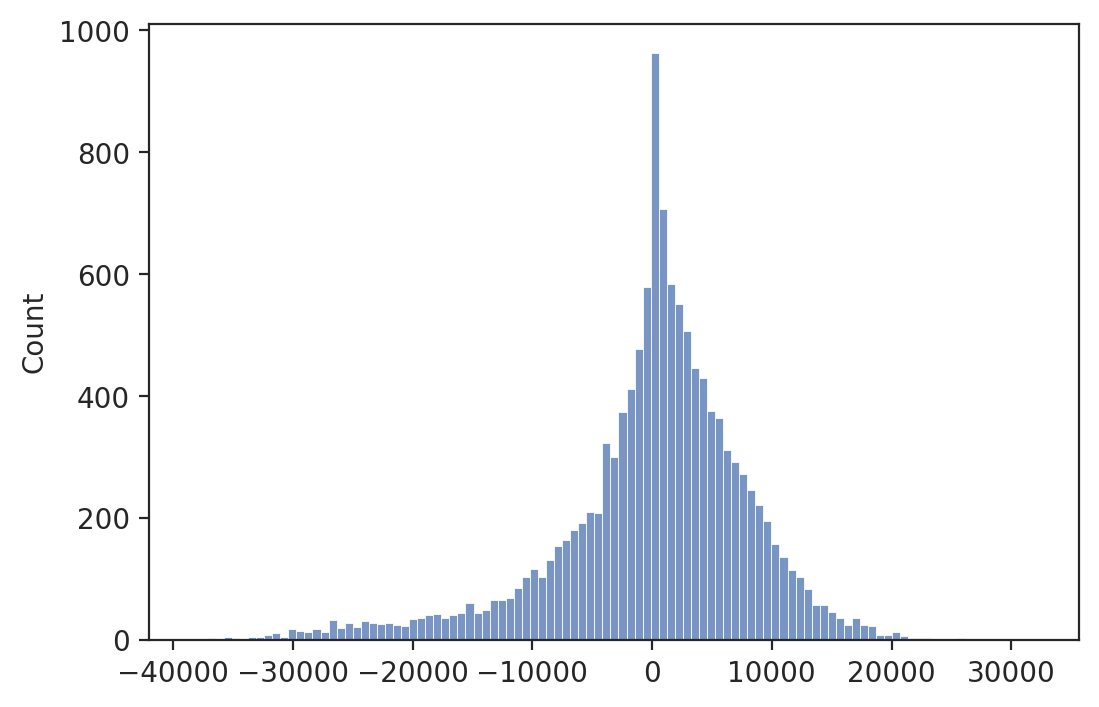

In [ ]:
sns.histplot(residuals_test);

In [ ]:
residuals_test.head()

,0
196111,418.8
317315,-15336.2
86496,-93.0
196660,2333.0
136579,-2427.0


In [ ]:
# Concatenate X_test with actual and predicted y -

residuals_test = residuals_test.rename('residual')

In [ ]:
test_with_residuals = pd.concat([ X_test, y_test, y_pred, residuals_test ], axis='columns')

In [ ]:
test_with_residuals

,mileage,vehicle_condition,year_of_registration,crossover_car_and_van,fuel_type_Diesel,fuel_type_Petrol,fuel_type_infrequent_sklearn,standard_colour_Black,standard_colour_White,standard_colour_infrequent_sklearn,...,standard_model_Hatch,standard_model_Juke,standard_model_Polo,standard_model_Qashqai,standard_model_Sportage,standard_model_Yaris,standard_model_infrequent_sklearn,price,y_pred,residual
196111,35124.0,1,2017.0,0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12500,12918.8,418.8
317315,41473.0,1,2016.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28950,13613.8,-15336.2
86496,0.0,0,2020.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15300,15207.0,-93.0
196660,29944.0,1,2018.0,0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10495,12828.0,2333.0
136579,30543.0,1,2017.0,0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14500,12073.0,-2427.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135183,47800.0,1,2016.0,0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,22990,9315.8,-13674.2
167688,85694.0,1,2015.0,0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8491,7944.0,-547.0
182733,44501.0,1,2015.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4500,17857.0,13357.0
344558,33974.0,1,2015.0,0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10599,9410.4,-1188.6


In [ ]:
test_with_residuals = test_with_residuals.rename(columns={'y_actual':'residual'})

In [ ]:
test_with_residuals.sort_values(by='residual')

,mileage,vehicle_condition,year_of_registration,crossover_car_and_van,fuel_type_Diesel,fuel_type_Petrol,fuel_type_infrequent_sklearn,standard_colour_Black,standard_colour_White,standard_colour_infrequent_sklearn,...,standard_model_Hatch,standard_model_Juke,standard_model_Polo,standard_model_Qashqai,standard_model_Sportage,standard_model_Yaris,standard_model_infrequent_sklearn,price,y_pred,residual
57434,45000.0,1,2011.0,0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,43200,4747.0,-38453.0
321230,21000.0,1,2012.0,0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,43200,5957.0,-37243.0
307628,64900.0,1,2014.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,43200,6093.2,-37106.8
24616,35000.0,1,2013.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,43200,6401.6,-36798.4
295864,48000.0,1,2010.0,0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,43200,7064.0,-36136.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253740,120.0,1,2020.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13715,40259.0,26544.0
10960,10278.0,1,2017.0,0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6600,33879.2,27279.2
310043,6558.0,1,2017.0,0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9295,37609.0,28314.0
113676,1853.0,1,2019.0,0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12199,42156.0,29957.0


In [ ]:
adv.loc[[57434,352430]].T

,57434,352430
mileage,45000.0,1852.0
standard_colour,White,Grey
standard_make,Porsche,Peugeot
standard_model,911,2008
vehicle_condition,1,1
year_of_registration,2011.0,2017.0
price,43200,9991
body_type,Convertible,SUV
crossover_car_and_van,0,0
fuel_type,Petrol,Petrol


In [ ]:
# show average mileage and price for vehicles with year_of_registration 2016

vehicles_2017 = adv[adv['year_of_registration'] == 2017]
vehicles_2017[['mileage','price']].mean().round(2)

,0
mileage,28759.57
price,15403.80


In [ ]:
adv_sub.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 78708 to 128054
Data columns (total 63 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   mileage                             50000 non-null  float64
 1   vehicle_condition                   50000 non-null  int64  
 2   year_of_registration                50000 non-null  float64
 3   price                               50000 non-null  int64  
 4   crossover_car_and_van               50000 non-null  int64  
 5   fuel_type_Diesel                    50000 non-null  float64
 6   fuel_type_Petrol                    50000 non-null  float64
 7   fuel_type_infrequent_sklearn        50000 non-null  float64
 8   standard_colour_Black               50000 non-null  float64
 9   standard_colour_White               50000 non-null  float64
 10  standard_colour_infrequent_sklearn  50000 non-null  float64
 11  body_type_Convertible               50000

In [ ]:
adv_porshce=adv.loc[adv['standard_make']=='Porsche']
adv_porshce.head()

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
140,70000.0,Black,Porsche,Boxster,1,2005.0,9950,Convertible,0,Petrol
155,50179.0,Blue,Porsche,Boxster,1,2016.0,33992,Convertible,0,Petrol
216,50.0,Silver,Porsche,Cayenne,1,2020.0,43200,SUV,0,Petrol
278,75000.0,Black,Porsche,911,1,2014.0,43200,Convertible,0,Petrol
283,31573.0,White,Porsche,Panamera,1,2014.0,31789,Hatchback,0,Diesel


In [ ]:
adv_porshce.describe().round(2)

,mileage,vehicle_condition,year_of_registration,price,crossover_car_and_van
count,4196.00,4196.0,4196.00,4196.00,4196.0
mean,38486.03,1.0,2012.86,34435.06,0.0
std,30688.62,0.0,6.25,11317.78,0.0
min,6.00,1.0,1990.00,2495.00,0.0
25%,11000.00,1.0,2009.00,26990.00,0.0
50%,32741.50,1.0,2015.00,42629.50,0.0
75%,60495.50,1.0,2018.00,43200.00,0.0
max,103032.50,1.0,2020.00,43200.00,0.0


In [ ]:
adv_peugeot=adv.loc[adv['standard_make']=='Peugeot']
adv_peugeot.describe().round(2)

,mileage,vehicle_condition,year_of_registration,price,crossover_car_and_van
count,15122.00,15122.00,15122.00,15122.00,15122.00
mean,35721.14,0.96,2015.32,10030.62,0.00
std,29389.01,0.20,3.96,7061.22,0.04
min,0.00,0.00,1990.00,2495.00,0.00
25%,12678.25,1.00,2013.00,4990.00,0.00
50%,26913.00,1.00,2017.00,8056.00,0.00
75%,54063.00,1.00,2018.00,12995.00,0.00
max,103032.50,1.00,2020.00,43200.00,1.00


In [ ]:
adv_peugeot = adv.loc[(adv['standard_make'] == 'Peugeot') & (adv['body_type'] == 'SUV')]
adv_peugeot.head()
adv_peugeot.describe().round(2)

,mileage,vehicle_condition,year_of_registration,price,crossover_car_and_van
count,4766.00,4766.00,4766.00,4766.00,4766.0
mean,27995.13,0.94,2016.95,14467.96,0.0
std,24058.04,0.23,2.41,7417.00,0.0
min,0.00,0.00,2007.00,2495.00,0.0
25%,11439.00,1.00,2016.00,8975.50,0.0
50%,21102.50,1.00,2017.00,12995.00,0.0
75%,38049.75,1.00,2019.00,19000.00,0.0
max,103032.50,1.00,2020.00,43200.00,0.0


In [ ]:
adv_SUV=adv.loc[adv['body_type']=='SUV']
adv_SUV.describe().round(2)

,mileage,vehicle_condition,year_of_registration,price,crossover_car_and_van
count,115462.00,115462.00,115462.00,115462.00,115462.00
mean,28770.63,0.87,2016.84,20560.11,0.00
std,28699.73,0.34,3.26,11243.32,0.05
min,0.00,0.00,1990.00,2495.00,0.00
25%,5070.25,1.00,2016.00,11970.00,0.00
50%,20286.00,1.00,2017.00,17900.00,0.00
75%,43156.50,1.00,2019.00,27389.50,0.00
max,103032.50,1.00,2020.00,43200.00,1.00
